In [27]:
import pandas as pd

In [28]:
df = pd.read_csv('heart.csv')

In [29]:
df.shape

(1025, 14)

In [30]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [31]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [32]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [33]:
import matplotlib.pyplot as plt

<Axes: xlabel='target'>

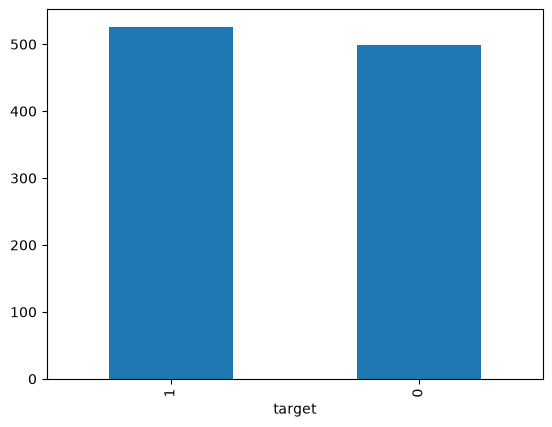

In [34]:
df['target'].value_counts().plot(kind='bar')

In [35]:
type(df)

pandas.DataFrame

In [36]:
type(df['target'])

pandas.Series

In [37]:
df['target'].value_counts()


target
1    526
0    499
Name: count, dtype: int64

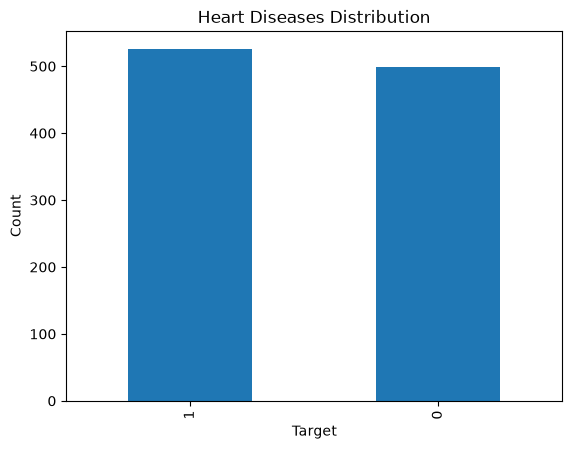

In [38]:
df['target'].value_counts().plot(kind='bar')
plt.title('Heart Diseases Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

## EDA - Finding 1: Target Distribution
- 526 patients have heart disease (target = 1)
- 499 patients have no heart disease (target = 0)
- Dataset is nearly balanced (51.3% vs 48.7%)
- This is ideal for ML — model cannot cheat by predicting one class always
- Both classes are well represented, so model will learn real patterns

In [39]:
import sys

In [40]:
!{sys.executable} -m pip install seaborn 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [42]:
df = pd.read_csv('heart.csv')


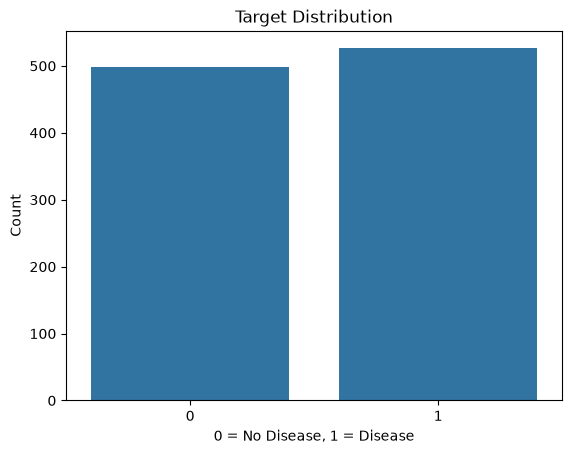

In [43]:
sns.countplot(x=df['target'])
plt.title('Target Distribution')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.show()

## Univariate Analysis — Finding 1: Target Column
- 1 (disease) = 526 patients
- 0 (no disease) = 499 patients  
- Dataset is balanced — 51.3% vs 48.7%
- Model cannot cheat by predicting one class always
- Both classes well represented = model will learn real patterns

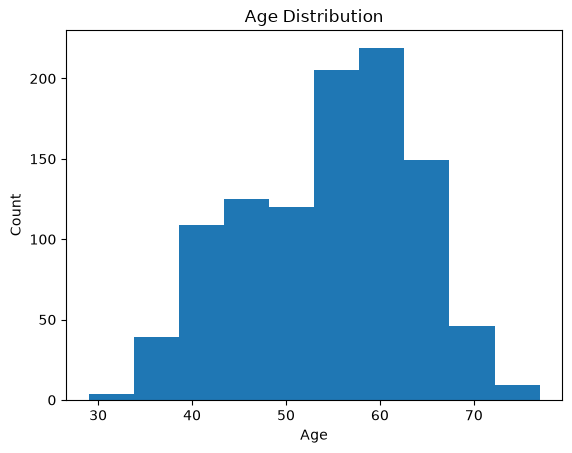

In [44]:
plt.hist(df['age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [45]:
print(df['age'].min())
print(df['age'].max())
print(df['age'].mean())
print(df['age'].skew())

29
77
54.43414634146342
-0.24886590174584555


126
564
246.0
1.0740727783354815


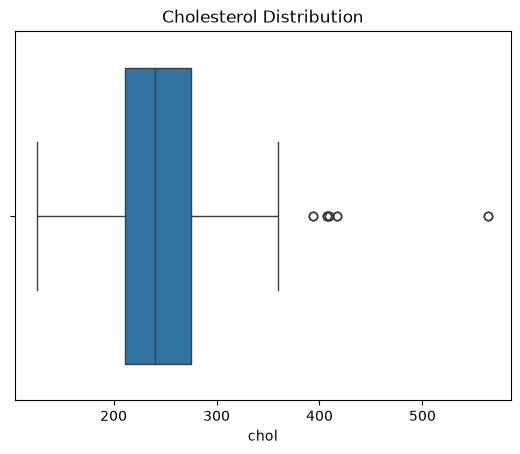

In [46]:
print(df['chol'].min())
print(df['chol'].max())
print(df['chol'].mean())
print(df['chol'].skew())

sns.boxplot(x=df['chol'])
plt.title('Cholesterol Distribution')
plt.show()

## Univariate Analysis — Finding 3: Cholesterol Column
- Range: 126 to 564
- Mean: 246 (already above high threshold of 240)
- Skew: 1.07 (severe positive skew)
- Outliers present — value of 564 is nearly 3x normal cholesterol
- ACTION NEEDED: transformation required during preprocessing
- Possible fix: log transformation or outlier removal